In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("D:\\work_dsi\\Supply_Chain_Project\\data\\DataCoSupplyChainDataset.csv",encoding='latin-1')

print("Dataset loaded successfully!")
print("Number of shipment orders:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of shipment orders: 180519
Number of columns: 53


In [4]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [9]:
df.sample(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
143624,TRANSFER,6,2,12.300000,122.949997,Shipping canceled,0,46,Indoor/Outdoor Games,Caguas,...,NaN,1014,46,NaN,http://images.acmesports.sports/O%27Brien+Men%...,O'Brien Men's Neoprene Life Vest,49.980000,0,9/15/2015 17:20,Second Class
54234,DEBIT,3,4,71.250000,189.990005,Advance shipping,0,48,Water Sports,Caguas,...,NaN,1073,48,NaN,http://images.acmesports.sports/Pelican+Sunstr...,Pelican Sunstream 100 Kayak,199.990005,0,6/29/2017 13:16,Standard Class
111695,DEBIT,3,2,-147.210007,191.919998,Late delivery,1,46,Indoor/Outdoor Games,Caguas,...,NaN,1014,46,NaN,http://images.acmesports.sports/O%27Brien+Men%...,O'Brien Men's Neoprene Life Vest,49.980000,0,12/17/2016 18:26,Second Class
98447,DEBIT,6,4,16.340000,49.500000,Late delivery,1,24,Women's Apparel,Bristol,...,NaN,502,24,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,10/27/2016 10:27,Standard Class
90122,PAYMENT,4,2,25.520000,88.000000,Late delivery,1,24,Women's Apparel,Caguas,...,85705.0,502,24,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,4/28/2016 1:15,Second Class


In [5]:
for i, column in enumerate(df.columns):
    print(f"{i+1}.{column}")

1.Type
2.Days for shipping (real)
3.Days for shipment (scheduled)
4.Benefit per order
5.Sales per customer
6.Delivery Status
7.Late_delivery_risk
8.Category Id
9.Category Name
10.Customer City
11.Customer Country
12.Customer Email
13.Customer Fname
14.Customer Id
15.Customer Lname
16.Customer Password
17.Customer Segment
18.Customer State
19.Customer Street
20.Customer Zipcode
21.Department Id
22.Department Name
23.Latitude
24.Longitude
25.Market
26.Order City
27.Order Country
28.Order Customer Id
29.order date (DateOrders)
30.Order Id
31.Order Item Cardprod Id
32.Order Item Discount
33.Order Item Discount Rate
34.Order Item Id
35.Order Item Product Price
36.Order Item Profit Ratio
37.Order Item Quantity
38.Sales
39.Order Item Total
40.Order Profit Per Order
41.Order Region
42.Order State
43.Order Status
44.Order Zipcode
45.Product Card Id
46.Product Category Id
47.Product Description
48.Product Image
49.Product Name
50.Product Price
51.Product Status
52.shipping date (DateOrders)
53.S

In [11]:
# Let's understand our target column — Late_delivery_risk
# value_counts() counts how many 0s and 1s exist
# This tells us if our dataset is balanced or imbalanced

print("Target column distribution:")
print("="*40)
print(df['Late_delivery_risk'].value_counts())
print()
print("Percentage:")
print(df['Late_delivery_risk'].value_counts(normalize=True).round(2) * 100)

Target column distribution:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Percentage:
Late_delivery_risk
1    55.0
0    45.0
Name: proportion, dtype: float64


In [6]:
# Missing values are empty cells in our dataset
# Like blank cells in Excel
# ML models cannot handle missing values — we need to find and fix them
# isnull() marks every empty cell as True
# sum() counts how many True values exist per column
# We only show columns that actually have missing values

import numpy as np

print("Columns with missing values:")
print("="*40)

missing = df.isnull().sum()
missing = missing[missing > 0]
missing_percent = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent
})

print(missing_df.sort_values('Missing Percentage', ascending=False))

Columns with missing values:
                     Missing Count  Missing Percentage
Product Description         180519              100.00
Order Zipcode               155679               86.24
Customer Zipcode                 3                0.00
Customer Lname                   8                0.00


In [7]:
# We select only the columns relevant to delay prediction
# Dropping personal info, empty columns, and irrelevant data

columns_to_keep = [
    'Late_delivery_risk',      # TARGET — what we predict
    'Shipping Mode',           # how it was shipped
    'Days for shipping (real)',# actual days taken
    'Days for shipment (scheduled)', # promised days
    'Delivery Status',         # current delivery status
    'Category Name',           # product category
    'Customer Segment',        # Consumer, Corporate, Home Office
    'Department Name',         # which department
    'Market',                  # which global market
    'Order Region',            # specific region
    'Order Item Quantity',     # number of items ordered
    'Order Item Discount Rate',# discount applied
    'Order Item Profit Ratio', # profit ratio
    'Sales per customer',      # sales value
    'order date (DateOrders)', # when order was placed
    'Type'                     # payment type
]

# Create a new DataFrame with only our selected columns
df_clean = df[columns_to_keep].copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)
print()
print("Columns we are working with:")
for i, col in enumerate(df_clean.columns):
    print(f"{i+1}. {col}")

Original dataset shape: (180519, 53)
Cleaned dataset shape: (180519, 16)

Columns we are working with:
1. Late_delivery_risk
2. Shipping Mode
3. Days for shipping (real)
4. Days for shipment (scheduled)
5. Delivery Status
6. Category Name
7. Customer Segment
8. Department Name
9. Market
10. Order Region
11. Order Item Quantity
12. Order Item Discount Rate
13. Order Item Profit Ratio
14. Sales per customer
15. order date (DateOrders)
16. Type


In [8]:
# df.dtypes tells us what type of data each column contains
# int64 = whole numbers (like 1, 2, 3)
# float64 = decimal numbers (like 1.5, 2.7)
# object = text/string (like "Standard Class", "Consumer")
# This is critical because ML models only understand numbers
# Any column showing 'object' needs to be converted to numbers later

print("Data types of each column:")
print("="*40)
print(df_clean.dtypes)

Data types of each column:
Late_delivery_risk                 int64
Shipping Mode                        str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Delivery Status                      str
Category Name                        str
Customer Segment                     str
Department Name                      str
Market                               str
Order Region                         str
Order Item Quantity                int64
Order Item Discount Rate         float64
Order Item Profit Ratio          float64
Sales per customer               float64
order date (DateOrders)              str
Type                                 str
dtype: object


In [9]:
# For each text column, let's see what unique values exist
# This tells us exactly what categories are in each column
# Like checking what options exist in an Excel dropdown

text_columns = [
    'Shipping Mode', 
    'Delivery Status', 
    'Customer Segment',
    'Market',
    'Type'
]

for col in text_columns:
    print(f"\n{col}:")
    print("="*40)
    print(df_clean[col].value_counts())


Shipping Mode:
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

Delivery Status:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Customer Segment:
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Market:
Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64

Type:
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64


In [10]:
# We remove columns that would cause data leakage
# These columns reveal the answer AFTER the fact
# In real world we wouldn't have this information at order placement time

# Drop leaky columns
leaky_columns = [
    'Delivery Status',           # directly reveals if delivery was late
    'Days for shipping (real)',   # only known after delivery
    'Order Item Profit Ratio'     # calculated after the sale completes
]

df_clean = df_clean.drop(columns=leaky_columns)

print("Columns after removing leaky ones:")
print("="*40)
for i, col in enumerate(df_clean.columns):
    print(f"{i+1}. {col}")

print(f"\nFinal shape: {df_clean.shape}")

Columns after removing leaky ones:
1. Late_delivery_risk
2. Shipping Mode
3. Days for shipment (scheduled)
4. Category Name
5. Customer Segment
6. Department Name
7. Market
8. Order Region
9. Order Item Quantity
10. Order Item Discount Rate
11. Sales per customer
12. order date (DateOrders)
13. Type

Final shape: (180519, 13)


In [11]:
# Our 'order date (DateOrders)' column is currently a text string
# like "1/31/2018 22:56" — ML models cannot learn from raw dates
# We need to extract useful NUMBER features from it
# For example:
# - Which month? (January has different patterns than December)
# - Which day of week? (Friday orders might be delayed over weekend)
# - Which hour? (Late night orders processed next day)

# First convert text to proper datetime format
df_clean['order date (DateOrders)'] = pd.to_datetime(
    df_clean['order date (DateOrders)']
)

# Now extract useful features from the date
df_clean['order_month'] = df_clean['order date (DateOrders)'].dt.month
df_clean['order_day_of_week'] = df_clean['order date (DateOrders)'].dt.dayofweek
df_clean['order_hour'] = df_clean['order date (DateOrders)'].dt.hour

# Drop the original date column — we extracted everything useful from it
df_clean = df_clean.drop(columns=['order date (DateOrders)'])

print("Date features extracted successfully!")
print()
print("New columns added:")
print("- order_month: 1=January, 12=December")
print("- order_day_of_week: 0=Monday, 6=Sunday")
print("- order_hour: 0-23")
print()
print("Sample of new date features:")
print(df_clean[['order_month', 'order_day_of_week', 'order_hour']].sample(5))

Date features extracted successfully!

New columns added:
- order_month: 1=January, 12=December
- order_day_of_week: 0=Monday, 6=Sunday
- order_hour: 0-23

Sample of new date features:
        order_month  order_day_of_week  order_hour
108612            5                  1           9
113278            9                  0           8
83341             9                  0           5
138470            3                  2          22
170025            7                  4          23


In [15]:
# ML models only understand numbers — not text like "Standard Class"
# We use Label Encoding to convert text to numbers
# For example:
# "Standard Class" → 0
# "First Class"    → 1
# "Second Class"   → 2
# "Same Day"       → 3

# We import LabelEncoder from scikit-learn
from sklearn.preprocessing import LabelEncoder

# Identify all text columns remaining
text_columns = df_clean.select_dtypes(include=['object']).columns.tolist()

print("Text columns to encode:")
print(text_columns)
print()

# Create a LabelEncoder object
le = LabelEncoder()

# Loop through each text column and encode it
for col in text_columns:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"✓ {col} encoded successfully")

print()
print("All text columns converted to numbers!")
print()
print("Final data types:")
print(df_clean.dtypes)

Text columns to encode:
[]


All text columns converted to numbers!

Final data types:
Late_delivery_risk                 int64
Shipping Mode                      int64
Days for shipment (scheduled)      int64
Category Name                      int64
Customer Segment                   int64
Department Name                    int64
Market                             int64
Order Region                       int64
Order Item Quantity                int64
Order Item Discount Rate         float64
Sales per customer               float64
Type                               int64
order_month                        int32
order_day_of_week                  int32
order_hour                         int32
dtype: object


In [16]:
# Final look at our clean dataset before training
print("="*40)
print("CLEAN DATASET SUMMARY")
print("="*40)
print(f"Total orders: {df_clean.shape[0]:,}")
print(f"Total features: {df_clean.shape[1]}")
print()
print(f"Target column: Late_delivery_risk")
print(f"Delayed orders: {df_clean['Late_delivery_risk'].sum():,} ({df_clean['Late_delivery_risk'].mean()*100:.1f}%)")
print(f"On time orders: {(df_clean['Late_delivery_risk']==0).sum():,} ({(df_clean['Late_delivery_risk']==0).mean()*100:.1f}%)")
print()
print("Features our model will learn from:")
features = [col for col in df_clean.columns if col != 'Late_delivery_risk']
for i, f in enumerate(features):
    print(f"  {i+1}. {f}")

# Save clean data for later use
df_clean.to_csv('data/clean_supply_chain_data.csv', index=False)
print()
print("✅ Clean data saved to data/clean_supply_chain_data.csv")

CLEAN DATASET SUMMARY
Total orders: 180,519
Total features: 15

Target column: Late_delivery_risk
Delayed orders: 98,977 (54.8%)
On time orders: 81,542 (45.2%)

Features our model will learn from:
  1. Shipping Mode
  2. Days for shipment (scheduled)
  3. Category Name
  4. Customer Segment
  5. Department Name
  6. Market
  7. Order Region
  8. Order Item Quantity
  9. Order Item Discount Rate
  10. Sales per customer
  11. Type
  12. order_month
  13. order_day_of_week
  14. order_hour

✅ Clean data saved to data/clean_supply_chain_data.csv


In [17]:
# We import train_test_split from scikit-learn
# This function randomly splits our data into training and testing sets
from sklearn.model_selection import train_test_split

# X = all feature columns (everything except our target)
# y = target column (what we want to predict)
X = df_clean.drop(columns=['Late_delivery_risk'])
y = df_clean['Late_delivery_risk']

# Split into 80% training and 20% testing
# random_state=42 ensures same split every time we run
# stratify=y ensures both sets have same ratio of 0s and 1s
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data split successfully!")
print()
print(f"Training set: {X_train.shape[0]:,} orders ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set:  {X_test.shape[0]:,} orders ({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print(f"Features per order: {X_train.shape[1]}")
print()
print(f"Delayed in training: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Delayed in testing:  {y_test.sum():,} ({y_test.mean()*100:.1f}%)")

Data split successfully!

Training set: 144,415 orders (80%)
Testing set:  36,104 orders (20%)

Features per order: 14

Delayed in training: 79,181 (54.8%)
Delayed in testing:  19,796 (54.8%)


In [18]:
# Import all three models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Import metrics to evaluate each model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define all three models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

# Train each model and evaluate it
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train the model on training data
    model.fit(X_train, y_train)
    
    # Make predictions on test data
    y_pred = model.predict(X_test)
    
    # Calculate evaluation metrics
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    }
    
    print(f"✅ {name} done!")
    print()

print("All models trained successfully!")

Training Logistic Regression...


d:\work_dsi\Supply_Chain_Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ Logistic Regression done!

Training Random Forest...
✅ Random Forest done!

Training XGBoost...
✅ XGBoost done!

All models trained successfully!


In [19]:
# Convert results to a DataFrame for clean comparison
import pandas as pd

results_df = pd.DataFrame(results).T.round(4) * 100

print("="*55)
print("MODEL COMPARISON RESULTS")
print("="*55)
print(results_df.to_string())
print()

# Find the best model
best_model_name = results_df['F1 Score'].idxmax()
print(f"🏆 Best Model: {best_model_name}")
print(f"   F1 Score: {results_df.loc[best_model_name, 'F1 Score']:.2f}%")
print(f"   Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.2f}%")

MODEL COMPARISON RESULTS
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression     68.99      78.78   59.46     67.77
Random Forest           73.96      80.98   68.63     74.29
XGBoost                 72.02      82.47   62.19     70.91

🏆 Best Model: Random Forest
   F1 Score: 74.29%
   Accuracy: 73.96%


In [20]:
# We save our best model to a file
# This means we don't need to retrain it every time
# We can just load it in our Streamlit app directly
# pickle is Python's way of saving any object to a file
import pickle

# Our best model is Random Forest
best_model = models['Random Forest']

# Save it to our models folder
with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Also save the feature names — we need these later in the app
feature_names = X_train.columns.tolist()

with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("✅ Best model saved to models/best_model.pkl")
print("✅ Feature names saved to models/feature_names.pkl")
print()
print(f"Model type: Random Forest")
print(f"Trained on: {X_train.shape[0]:,} orders")
print(f"Features used: {X_train.shape[1]}")
print(f"F1 Score: 74.29%")
print(f"Accuracy: 73.96%")

✅ Best model saved to models/best_model.pkl
✅ Feature names saved to models/feature_names.pkl

Model type: Random Forest
Trained on: 144,415 orders
Features used: 14
F1 Score: 74.29%
Accuracy: 73.96%


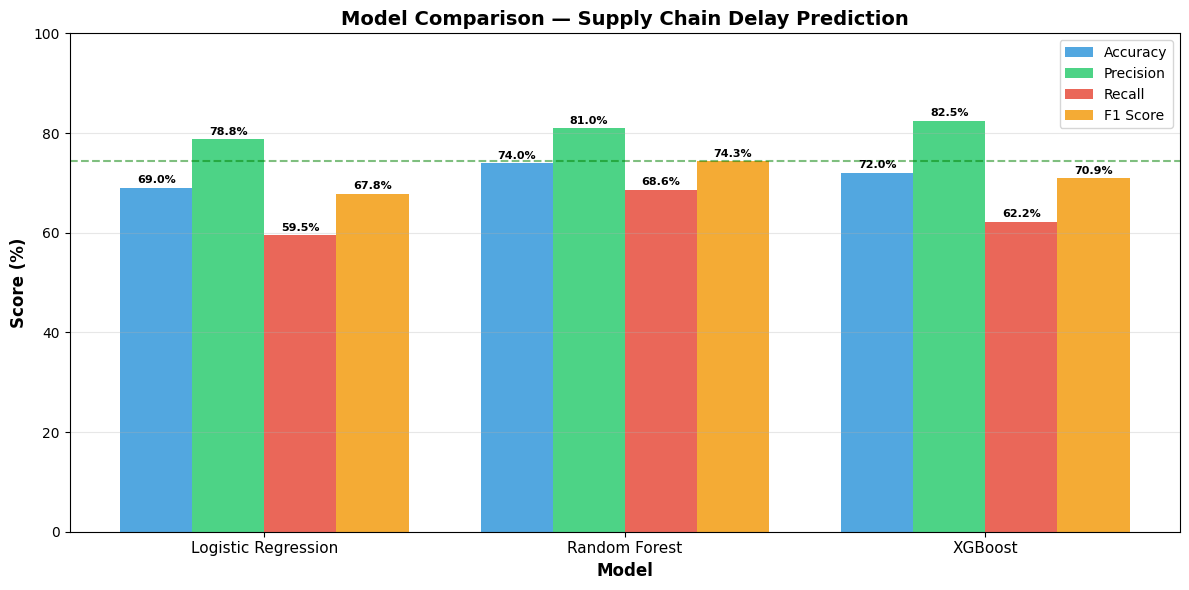

✅ Chart saved to outputs/model_comparison.png


In [21]:
# Let's create a professional chart comparing all three models
# This chart will go into your GitHub and looks great in a portfolio
import matplotlib.pyplot as plt
import numpy as np

# Data for chart
model_names = list(results.keys())
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

# Set up the chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(model_names))
width = 0.2

# Plot bars for each metric
for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = [results[model][metric] * 100 for model in model_names]
    bars = ax.bar(x + i * width, values, width, label=metric, color=color, alpha=0.85)
    
    # Add value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )

# Chart formatting
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison — Supply Chain Delay Prediction', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 100)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=74.29, color='green', linestyle='--', alpha=0.5, label='Best F1')

plt.tight_layout()

# Save chart to outputs folder
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to outputs/model_comparison.png")

In [24]:
# SHAP helps us understand WHY our model makes each prediction
# We import shap library
import shap

# Create a SHAP explainer for our Random Forest model
# TreeExplainer is specifically designed for tree-based models
# like Random Forest and XGBoost
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for our test set
# We use first 500 rows only — calculating for all 36,000 would take too long
# 500 rows is more than enough to understand patterns
print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test[:500])

print("✅ SHAP values calculated successfully!")
print()
print(f"Shape of SHAP values: {shap_values[1].shape}")
print(f"This means: 500 orders × {X_test.shape[1]} features")
print()
print("Each number tells us how much each feature")
print("pushed the prediction toward delayed or on time")

Calculating SHAP values...
✅ SHAP values calculated successfully!

Shape of SHAP values: (14, 2)
This means: 500 orders × 14 features

Each number tells us how much each feature
pushed the prediction toward delayed or on time


In [27]:
# Let's first understand what format our SHAP values are in
print("Type of shap_values:", type(shap_values))
print()

if isinstance(shap_values, list):
    print("shap_values is a LIST")
    print("Number of elements:", len(shap_values))
    for i, sv in enumerate(shap_values):
        print(f"  shap_values[{i}] shape: {sv.shape}")
else:
    print("shap_values is an ARRAY")
    print("Shape:", shap_values.shape)

Type of shap_values: <class 'numpy.ndarray'>

shap_values is an ARRAY
Shape: (500, 14, 2)


Shape after slicing: (500, 14)
This is now: 500 orders × 14 features ✅



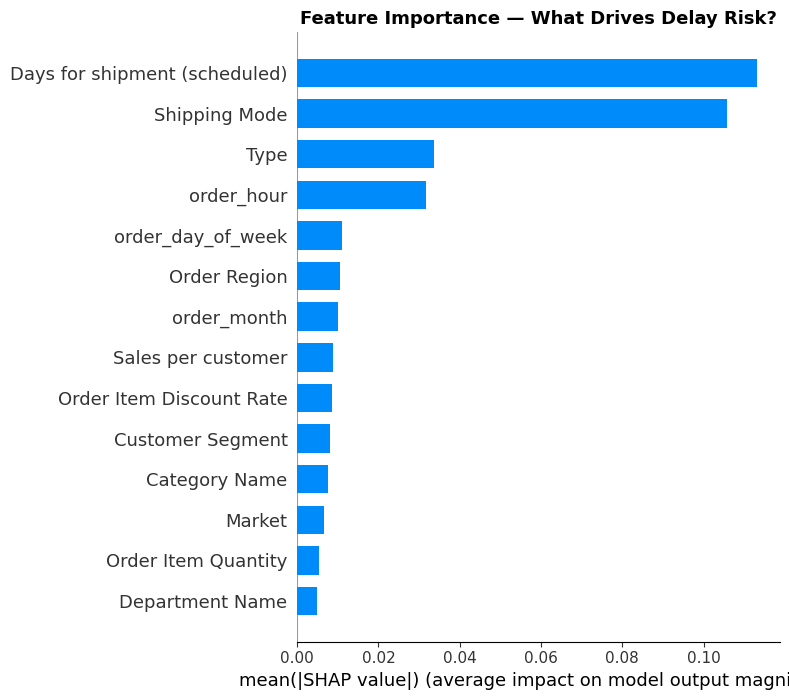

✅ SHAP chart saved!


In [28]:
# shap_values has shape (500, 14, 2)
# We want class 1 = delayed predictions
# So we take [:, :, 1] meaning:
# : = all 500 orders
# : = all 14 features
# 1 = delayed class only

shap_values_delayed = shap_values[:, :, 1]

print("Shape after slicing:", shap_values_delayed.shape)
print("This is now: 500 orders × 14 features ✅")
print()

# Now plot feature importance
shap.summary_plot(
    shap_values_delayed,
    X_test[:500],
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("Feature Importance — What Drives Delay Risk?",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ SHAP chart saved!")

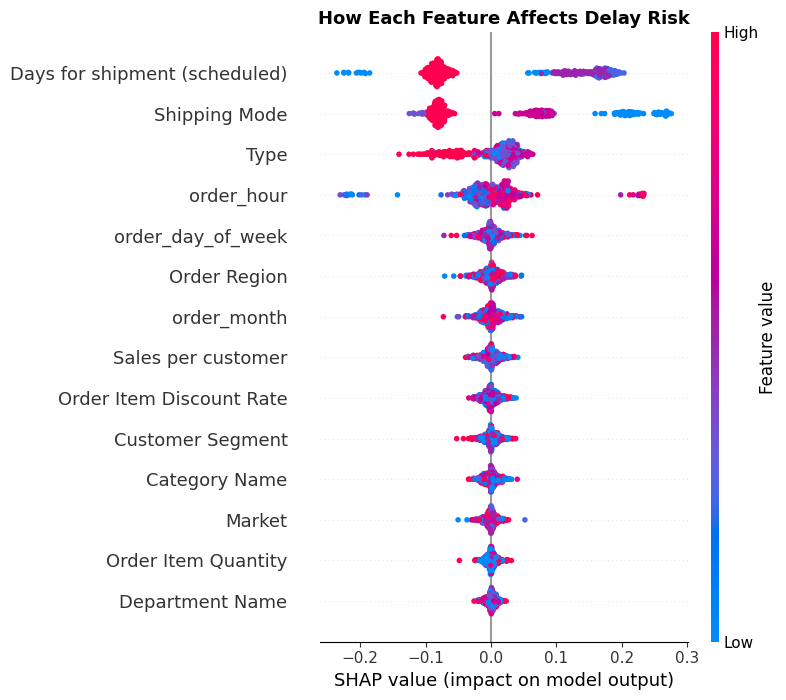

✅ SHAP dot plot saved!


In [29]:
# This plot shows not just WHICH features matter
# but HOW they affect the prediction
# Red = high value of that feature = pushes toward delayed
# Blue = low value of that feature = pushes toward on time

shap.summary_plot(
    shap_values_delayed,
    X_test[:500],
    feature_names=feature_names,
    plot_type="dot",          # dot plot shows direction of impact
    show=False
)

plt.title("How Each Feature Affects Delay Risk",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_dot_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ SHAP dot plot saved!")